# Wrapping a signal around a circle

An idea for **Notebook 13, section 3**, before `np.fft.rfft` shows up. No data needed.

Take a signal and multiply it by $e^{-2\pi i f t}$. That wraps it around a circle, going round $f$
times a second. Now look at where the **centre of mass** of the wrapped shape ends up. If the signal
contains that frequency, the loops pile up on one side and the centre of mass moves off the origin.
If it does not, they spread out evenly and it stays put. Try every winding speed and you have drawn
the spectrum by hand.

Same idea as the [3Blue1Brown video](https://www.youtube.com/watch?v=spUNpyF58BY) and the
[betterexplained page](https://betterexplained.com/articles/an-interactive-guide-to-the-fourier-transform/).
Run it with the `qmn` kernel.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import Video
from pathlib import Path

plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "font.size": 10})

ASSETS = Path("assets/13_winding")          # the animations are written here, not into this file
ASSETS.mkdir(parents=True, exist_ok=True)

fs = 2000                                  # a fine grid, only so the drawings come out smooth
t = np.arange(0, 1, 1 / fs)                # one second
signal = 1.0 * np.sin(2 * np.pi * 10 * t) + 0.5 * np.sin(2 * np.pi * 25 * t)

def wind(f):
    """Wrap the signal around a circle, f turns per second."""
    return signal * np.exp(-2j * np.pi * f * t)

for f in [5, 10, 25]:
    print(f"wound at {f:2d} Hz -> centre of mass {abs(wind(f).mean()):.2f} away from the origin")

wound at  5 Hz -> centre of mass 0.00 away from the origin
wound at 10 Hz -> centre of mass 0.50 away from the origin
wound at 25 Hz -> centre of mass 0.25 away from the origin


## Watch it wrap

The orange dot walks along the signal on the left, and the same dot walks around the circle on the
right, wrapped once at 5 Hz and once at 10 Hz. The red dot is the centre of mass of everything
wrapped so far. The signal has a 10 Hz component in it, so at 10 Hz the loops keep landing on the
same side and the red dot drifts away from the middle. At 5 Hz they land all over the place and it
stays home. Double the final distance and you have the amplitude of that frequency.

In [2]:
steps = 300                                # how many stops the walk makes
hold = 20                                  # frames to sit still at the end
w5, w10 = wind(5), wind(10)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))

axes[0].plot(t, signal, lw=1, color="0.8")
trace, = axes[0].plot([], [], lw=1.2, color="C0")
walker, = axes[0].plot([], [], "o", color="C1", ms=7)
axes[0].set_xlim(0, 1); axes[0].set_ylim(-1.8, 1.8)
axes[0].set_xlabel("time (s)"); axes[0].set_title("the signal")

drawn, heads, coms = [], [], []
for ax, w, f in zip(axes[1:], (w5, w10), (5, 10)):
    line, = ax.plot([], [], lw=0.7, color="C0")
    head, = ax.plot([], [], "o", color="C1", ms=6, label="where we are now")
    com, = ax.plot([], [], "o", color="C3", ms=9, label="centre of mass so far")
    ax.set_xlim(-1.7, 1.7); ax.set_ylim(-1.7, 1.7); ax.set_aspect("equal")
    ax.axhline(0, color="0.85", lw=0.8); ax.axvline(0, color="0.85", lw=0.8)
    ax.set_title(f"wrapped at {f} Hz")
    drawn.append(line); heads.append(head); coms.append(com)
axes[1].legend(loc="lower center", fontsize=8, frameon=False)

def draw(i):
    k = max(2, int(min(i + 1, steps) / steps * len(t)))
    trace.set_data(t[:k], signal[:k]); walker.set_data([t[k - 1]], [signal[k - 1]])
    for line, head, com, w in zip(drawn, heads, coms, (w5, w10)):
        line.set_data(w.real[:k], w.imag[:k])
        head.set_data([w.real[k - 1]], [w.imag[k - 1]])
        com.set_data([w.real[:k].mean()], [w.imag[:k].mean()])
    return [trace, walker] + drawn + heads + coms

fig.tight_layout()
FuncAnimation(fig, draw, frames=steps + hold).save(ASSETS / "wrapping.mp4",
                                                   writer=FFMpegWriter(fps=15, extra_args=["-pix_fmt", "yuv420p", "-crf", "28"]), dpi=90)
plt.close(fig)
Video(ASSETS / "wrapping.mp4", embed=True, html_attributes="controls loop", width=900)

## Now turn the winding speed up slowly

Same picture, but this time the wrapping speed increases and the curve on the right records how far
the centre of mass got at each speed. Two bumps go by, a big one at 10 Hz and a smaller one at
25 Hz, which is exactly what we put into the signal.

In [3]:
sweep = np.arange(1, 30.05, 0.125)                  # winding speeds to visit
found = [2 * abs(wind(f).mean()) for f in sweep]    # how far the centre of mass gets at each one

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
curve, = axes[0].plot([], [], lw=0.7, color="C0")
com, = axes[0].plot([], [], "o", color="C3", ms=9)
axes[0].set_xlim(-1.7, 1.7); axes[0].set_ylim(-1.7, 1.7); axes[0].set_aspect("equal")
axes[0].axhline(0, color="0.85", lw=0.8); axes[0].axvline(0, color="0.85", lw=0.8)

drawn, = axes[1].plot([], [], lw=2, color="C0")
axes[1].set_xlim(0, 30); axes[1].set_ylim(0, 1.2)
axes[1].set_xlabel("winding speed (Hz)"); axes[1].set_ylabel("how much of it is there")

def draw(i):
    w = wind(sweep[i])
    curve.set_data(w.real, w.imag)
    com.set_data([w.real.mean()], [w.imag.mean()])
    drawn.set_data(sweep[:i + 1], found[:i + 1])
    axes[0].set_title(f"wrapped at {sweep[i]:.1f} Hz")
    return curve, com, drawn

fig.tight_layout()
FuncAnimation(fig, draw, frames=len(sweep)).save(ASSETS / "sweeping.mp4",
                                                 writer=FFMpegWriter(fps=12, extra_args=["-pix_fmt", "yuv420p", "-crf", "28"]), dpi=90)
plt.close(fig)
Video(ASSETS / "sweeping.mp4", embed=True, html_attributes="controls loop", width=900)

## That curve is the FFT

Nothing above used `np.fft`. Laying the two on top of each other is the punchline: the thing the FFT
computes is the walk we just watched, done for every frequency at once and much faster.

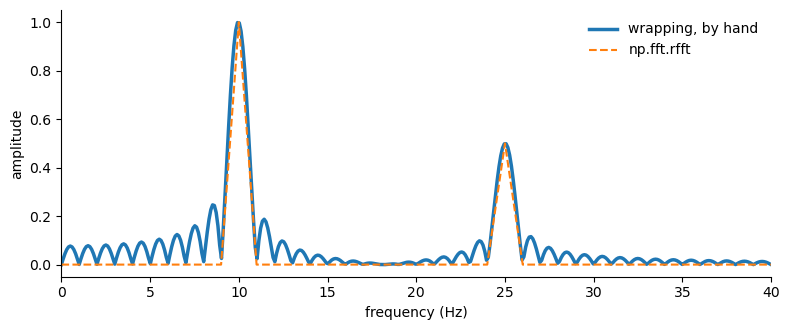

In [4]:
grid = np.linspace(0, 40, 400)
by_hand = [2 * abs(wind(f).mean()) for f in grid]

freqs = np.fft.rfftfreq(len(signal), d=1 / fs)
by_fft = np.abs(np.fft.rfft(signal)) / len(signal) * 2

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(grid, by_hand, lw=2.5, color="C0", label="wrapping, by hand")
ax.plot(freqs, by_fft, lw=1.5, ls="--", color="C1", label="np.fft.rfft")
ax.set_xlim(0, 40); ax.set_xlabel("frequency (Hz)"); ax.set_ylabel("amplitude")
ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## Notes

- Where it would go: Notebook 13 section 3, just before the first `np.fft.rfft`. It also sets up
  section 4, since the length of the arrow to the centre of mass is the amplitude and its angle is
  the phase.
- The two animations are rendered when you run the cells and then **embedded in the notebook**, so
  they play inline and travel with the file. The mp4 files are also left in
  `notebooks/assets/13_winding/` in case they are useful on their own.
- For a sharper copy to send to someone, `src/make_winding_animations.py` renders the same two
  animations at a higher resolution.
- The signal here is sampled at 2000 Hz purely so the loops look smooth on screen. The EEG in the
  real notebook is 256 Hz, and the same code works but the circles would be just a bit more "angular".
- A live slider with `ipywidgets` to make it intercative could be possible too, but maybe it would ebcome to heavy, not sure.